In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from stillib_plotting import despine, figure, save, set_axis_labels, use_style

from mscthesis.config import ProjectConfig
from mscthesis.core.io import load_dataframe
from mscthesis.paths import ProjectPaths

config = ProjectConfig()
paths = ProjectPaths(config.behavior.storage_root) 
df = load_dataframe(paths.diffusion_summary.require())

CMAP = "inferno"


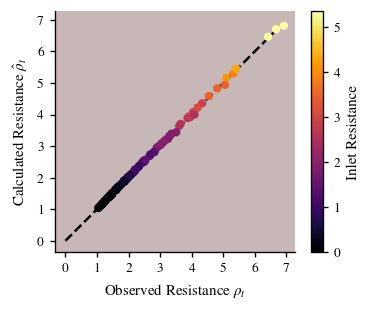

In [7]:

def format_comparison_plot(ax, max: float, step_ticks: float = 1.0) -> None:
    ax.plot([0, max], [0, max], 'k--', zorder=0)
    despine(ax)
    ax.set_facecolor("#C7B7B7")
    ax.set_aspect('equal')
    ticks = np.arange(0, max+step_ticks, step_ticks)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)


def plot_resistance_t_comparison(df: pd.DataFrame, color_key: str = "inlet_resistance") -> None:
    use_style() 
    fig, ax = figure()
    max_value = max(df['resistance_t'].max(), df['calculated_resistance_t'].max())
    sc = ax.scatter(df['resistance_t'], df['calculated_resistance_t'], c=df[color_key] if color_key in df.columns else None, cmap=CMAP, vmin=0)
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(color_key.replace('_', ' ').title())
    format_comparison_plot(ax, max_value)
    set_axis_labels(ax, r'Observed Resistance $\rho_t$', r'Calculated Resistance $\hat{\rho}_t$')

    return

plot_resistance_t_comparison(df, color_key="inlet_resistance")

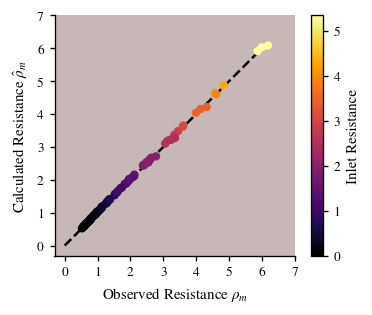

In [8]:
def plot_resistance_m_comparison(df: pd.DataFrame, color_key: str = "inlet_resistance") -> None:
    use_style() 
    fig, ax = figure()
    max_value = max(df['resistance_m'].max(), df['calculated_resistance_m'].max())
    sc = ax.scatter(df['resistance_m'], df['calculated_resistance_m'], c=df[color_key] if color_key in df.columns else None, cmap=CMAP, vmin=0)
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(color_key.replace('_', ' ').title())
    format_comparison_plot(ax, max_value)
    set_axis_labels(ax, r'Observed Resistance $\rho_m$', r'Calculated Resistance $\hat{\rho}_m$')
    plt.show()

    return

plot_resistance_m_comparison(df, color_key="inlet_resistance")

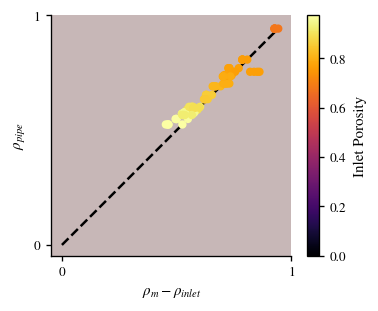

In [9]:
use_style()
fig, ax = figure()
x = df["resistance_m"] - df["inlet_resistance"]
y = df["pipe_resistance_m"]
max_value = max(x.max(), y.max())
sc = ax.scatter(x, y, c=df["porosity"], cmap=CMAP, vmin=0)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Inlet Porosity")
format_comparison_plot(ax, max_value)
set_axis_labels(ax, r'$\rho_m - \rho_{inlet}$', r'$\rho_{pipe}$')
plt.show()

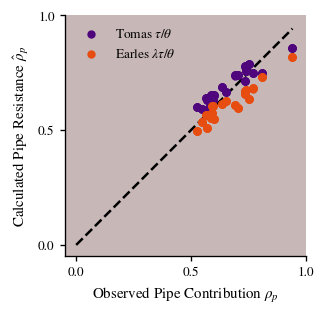

In [10]:
def plot_pipe_resistance_comparison(df: pd.DataFrame) -> None:
    use_style() 
    fig, ax = figure()
    max_value = max(df['pipe_resistance_m'].max(), df['standard_tomas'].max(), df["standard_earles"].max())
    keys = ["standard_tomas", "standard_earles"]
    labels = [r"Tomas $\tau/\theta$", r"Earles $\lambda\tau/\theta$"]
    colors = ["#4F067D", "#E74D11"]

    for key, label, color in zip(keys, labels, colors, strict=True):
        ax.scatter(df['pipe_resistance_m'], df[key], color=color, label=label)
    format_comparison_plot(ax, max_value, step_ticks=0.5)
    set_axis_labels(ax, r'Observed Pipe Contribution $\rho_p$', r'Calculated Pipe Resistance $\hat{\rho}_p$')
    ax.legend()
    return

plot_pipe_resistance_comparison(df)

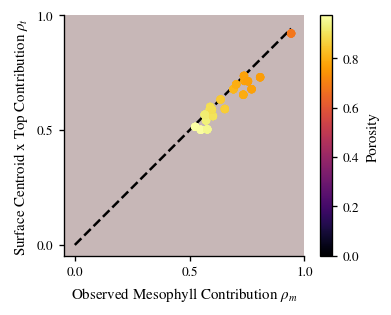

In [12]:
def plot_pipe_resistance_m_comparison(df: pd.DataFrame, color_key: str = "porosity") -> None:
    use_style() 
    fig, ax = figure()
    max_value = df['pipe_resistance_m'].max()
    sc = ax.scatter(df['pipe_resistance_m'], df["surface_centroid"]*df['pipe_resistance_t'], c=df[color_key] if color_key in df.columns else None, cmap=CMAP, vmin=0)
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(color_key.replace('_', ' ').title())
    format_comparison_plot(ax, max_value, step_ticks=0.5)
    set_axis_labels(ax, r'Observed Mesophyll Contribution $\rho_m$', r'Surface Centroid x Top Contribution $\rho_t$')
    return

plot_pipe_resistance_m_comparison(df)

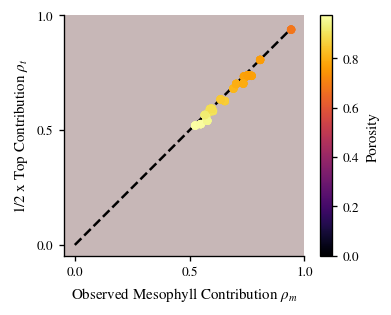

In [13]:
def plot_pipe_resistance_m_comparison_(df: pd.DataFrame, color_key: str = "porosity") -> None:
    use_style() 
    fig, ax = figure()
    max_value = df['pipe_resistance_m'].max()
    sc = ax.scatter(df['pipe_resistance_m'], 0.5*df['pipe_resistance_t'], c=df[color_key] if color_key in df.columns else None, cmap=CMAP, vmin=0)   

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(color_key.replace('_', ' ').title())
    format_comparison_plot(ax, max_value, step_ticks=0.5)
    set_axis_labels(ax, r'Observed Mesophyll Contribution $\rho_m$', r'1/2 x Top Contribution $\rho_t$')
    return

plot_pipe_resistance_m_comparison_(df)